# Stirling's Approximation: Absolute and Relative Error Analysis

**Exercise 1.4**

Write a program to compute the absolute and relative errors in Stirling's approximation

$$n! \approx \sqrt{2\pi n}\left(\frac{n}{e}\right)^n$$

for $n = 1, \ldots, 10$. Does the absolute error grow or shrink as $n$ increases? Does the relative error grow or shrink as $n$ increases?

---

This notebook computes both the exact factorial and Stirling's approximation for each $n$, then measures how far apart they are in absolute and relative terms.


## 1. Setup
Usaremos la librería `math` para calcular el factorial "real" y `math` para organizar los resultados en una tabla. 

In [ ]:
import math
import pandas as pd

## 2. Definición de variables, ¿Cómo obtendremos cada una? 

- **Valor exacto:** $n!$, cáculado con el método definido de math:  `math.factorial`.
- **Stirling's approximation:** Usando la fórmula dada: $\sqrt{2\pi n}\,(n/e)^n$.

Y las ya conocidas: 
- **Absolute error:** $E_a = |n! - \text{Stirling}(n)|$.
- **Relative error:** $r = E_a / n!$

In [ ]:
## Definimos una función para hacer los cálculos de n! exacto, n! aproximado y sus errores
def get_error_values(n):
    exact = math.factorial(n)
    approx = math.sqrt(2 * math.pi * n) * (n / math.e) ** n ## Stirling's approximation
    abs_err = abs(exact - approx)
    rel_err = abs_err / exact
    return exact, approx, abs_err, rel_err

## 3. Cálculo y visualización de resultados

- Recorreremos cada $n$ 
- Se aplicará la función definida anteriormente
- Se recopilarán los datos y serán formateados como un dataframe de pandas. 

In [ ]:
rows = []
for n in range(1, 11):
    exact, approx, abs_err, rel_err = get_error_values(n)
    rows.append({
        "n": n,
        "n!": exact,
        "Stirling": round(approx, 4),
        "Abs. Error": round(abs_err, 4),
        "Rel. Error": rel_err,
    })

df = pd.DataFrame(rows)
df

,n,n!,Stirling,Abs. Error,Rel. Error
0,1,1,9.221000e-01,0.0779,0.077863
1,2,2,1.919000e+00,0.0810,0.040498
2,3,6,5.836200e+00,0.1638,0.027298
3,4,24,2.350620e+01,0.4938,0.020576
4,5,120,1.180192e+02,1.9808,0.016507
5,6,720,7.100782e+02,9.9218,0.013780
6,7,5040,4.980396e+03,59.6042,0.011826
7,8,40320,3.990240e+04,417.6045,0.010357
8,9,362880,3.595369e+05,3343.1272,0.009213
9,10,3628800,3.598696e+06,30104.3813,0.008296


## 4. Observaciones: 

- **Error absoluto:** incrementa junto al crecimiento de $n$. Esto es entendible ya que tanto la aproximación como el valor real crecen ambos exponencialmente, dejando que la diferencia crezca también. 
- **Relative error:** Disminuye mistras as $n$ incrementa. Aunque parece ser anti-intuitivo, se debe notar que aunque el error absoluto crece, mo lo hace tan rápido como los cambios mismos de $n!$, causando que el radio decrezca poco a poco. 

Esto confirma que la aproximación de Stirling es proporcionalmente más precisa para valores más grandes de $n$.

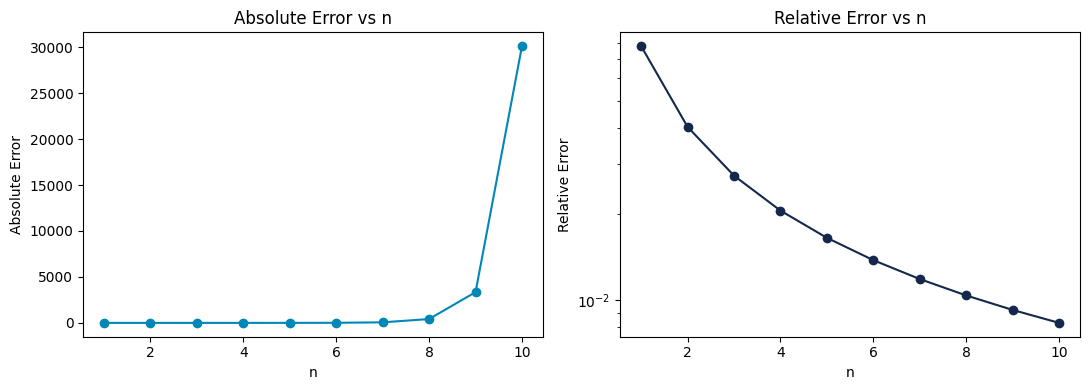

In [ ]:
#Extra: Visualizar las tendencias de los errores absolutos y relativos en función de n

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(df["n"], df["Abs. Error"], marker="o", color="#0087B7")
axes[0].set_title("Absolute Error vs n")
axes[0].set_xlabel("n")
axes[0].set_ylabel("Absolute Error")

axes[1].plot(df["n"], df["Rel. Error"], marker="o", color="#14284B")
axes[1].set_title("Relative Error vs n")
axes[1].set_xlabel("n")
axes[1].set_ylabel("Relative Error")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()
